<a href="https://colab.research.google.com/github/luisaschaefertrindade/semantic_loans/blob/main/curadoria_calques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Loans from English in Brazilian Portuguese
## Corpus Curation and Analysis

This notebook covers:
1. Upload and loading of curated Excel/CSV files
2. Overview of annotated data
3. Diachronic analysis: verb usage over time (*aplicar*, *candidatar*, *inscrever*)
4. Distribution by subreddit

In [ ]:
# ── 0. Dependencies ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import files

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)
print('Ready.')

Ready.


In [ ]:
# ── 1. Query → verb mapping ───────────────────────────────────────────────────
# Maps each query string to a canonical verb label used in the analysis.
# Extend this dictionary as new terms are added to the project.

QUERY_TO_VERB = {
    # apply — loan forms
    "apliquei":     "aplicar",
    "aplicou":      "aplicar",
    "aplicaram":    "aplicar",
    "aplicar":      "aplicar",
    # apply — native forms
    "candidatei":   "candidatar",
    "candidatou":   "candidatar",
    "candidataram": "candidatar",
    "candidatar":   "candidatar",
    "inscrevi":     "inscrever",
    "inscreveu":    "inscrever",
    "inscreveram":  "inscrever",
    "inscrever":    "inscrever",
}

# Loan forms per term — used to compute loan proportion
LOAN_FORMS = {
    "apply": ["aplicar"],
}

print('Verb mapping loaded:', len(QUERY_TO_VERB), 'query forms')

Verb mapping loaded: 12 query forms


In [ ]:
# ── 2. Upload curated files ───────────────────────────────────────────────────
# Upload one or more curated .xlsx or .csv files.

uploaded = files.upload()
print('Files uploaded:', list(uploaded.keys()))

Saving apply_1.csv to apply_1.csv
Saving apply_2.csv to apply_2.csv
Saving apply_3.csv to apply_3.csv
Saving apply_4.csv to apply_4.csv
Saving apply_5.csv to apply_5.csv
Saving apply_6.csv to apply_6.csv
Saving apply_7.csv to apply_7.csv
Saving apply_8.csv to apply_8.csv
Files uploaded: ['apply_1.csv', 'apply_2.csv', 'apply_3.csv', 'apply_4.csv', 'apply_5.csv', 'apply_6.csv', 'apply_7.csv', 'apply_8.csv']


In [ ]:
# ── 3. Load and prepare for annotation ───────────────────────────────────────────────────

dfs = []
for filename in uploaded.keys():
    if filename.endswith('.xlsx') or filename.endswith('.xls'):
        df = pd.read_excel(filename)
    else:
        df = pd.read_csv(filename)
    dfs.append(df)

dados = pd.concat(dfs, ignore_index=True)
dados['ano']   = pd.to_numeric(dados['ano'],   errors='coerce')
dados['score'] = pd.to_numeric(dados['score'], errors='coerce')

dados['categoria'] = ''

print(f'Total records: {len(dados)}')
print(f'Columns: {list(dados.columns)}')
dados.head(3)

Total records: 2673
Columns: ['termo', 'query', 'subreddit', 'id', 'created_utc', 'ano', 'score', 'body', 'permalink', 'verbo', 'categoria']


,termo,query,subreddit,id,created_utc,ano,score,body,permalink,verbo,categoria
0,apply,aplicou,BrasildoB,cyen6aa,1451364839,2015,4,"É uma forma muito crua de se referir à escola de Frankfurt, que aplicou a teoria marxista às relações sociais, e tam...",/r/BrasildoB/comments/t3_3ycbdp/cyen6aa,aplicar,
1,apply,aplicou,BrasildoB,d3vb27f,1465007356,2016,2,O monitoramento da população e a *surveillance* por parte dos governos não são novidades. É só lembrar do Snowden. O...,/r/BrasildoB/comments/t3_4mdre1/d3vb27f,aplicar,
2,apply,aplicou,BrasildoB,d6gg0vu,1471131228,2016,4,"Embora fosse um movimento antigo, Kissinger foi o homem que realmente aplicou o projeto que jogou a política e a eco...",/r/BrasildoB/comments/t3_4xkjrn/d6gg0vu,aplicar,


In [ ]:
# ── 4. Export curated data ────────────────────────────────────────────────────

dados.to_csv('apply_data.csv', index=False)
files.download('apply_data.csv')
print(f'Exported: apply_data.csv ({len(dados)} rows)')

In [ ]:
# ── 5. Upload curated file ──────────────────────────────────────────────

curado_upload = files.upload()
nome_arquivo  = list(curado_upload.keys())[0]

curado = pd.read_excel(nome_arquivo)

# only relevant cases
relevante = curado[curado['categoria'] == 'relevant'].copy()
print(f'Total curated: {len(curado)} | Relevants: {len(relevante)}')
print(relevante.groupby(['termo', 'tipo']).size().unstack(fill_value=0))

# map query → canonical verb
relevante['verbo'] = relevante['query'].str.strip().str.lower().map(QUERY_TO_VERB)
unmapped = relevante['verbo'].isna().sum()
if unmapped > 0:
    print(f'Warning: {unmapped} rows with unmapped query values:')
    print(relevante[relevante['verbo'].isna()]['query'].value_counts())

Saving curadoria_anotada.xlsm to curadoria_anotada (4).xlsm
Total curado: 2673 | Relevantes: 556
tipo   indefinido
termo            
apply         556


In [ ]:
# ── 6. Content overview ────────────────────────────────────────────────────

print('By category:')
print(relevante['categoria'].value_counts())
print()
print('By verb:')
print(relevante['verbo'].value_counts())
print()
print('By subreddit:')
print(relevante['subreddit'].value_counts())

By category:
categoria
relevant    556
Name: count, dtype: int64

By verb:
verbo
aplicar       195
candidatar    183
inscrever     178
Name: count, dtype: int64

By subreddit:
subreddit
desabafos    393
brdev        153
BrasildoB     10
Name: count, dtype: int64


In [ ]:
# ── 7. Filter relevant records ────────────────────────────────────────────────

relevante = relevante.dropna(subset=['ano', 'verbo'])
relevante['ano'] = relevante['ano'].astype(int)

print(f'Relevant records: {len(relevante)}')
print()
print('By verb:')
print(relevante['verbo'].value_counts())

Relevant records: 556

By verb:
verbo
aplicar       195
candidatar    183
inscrever     178
Name: count, dtype: int64


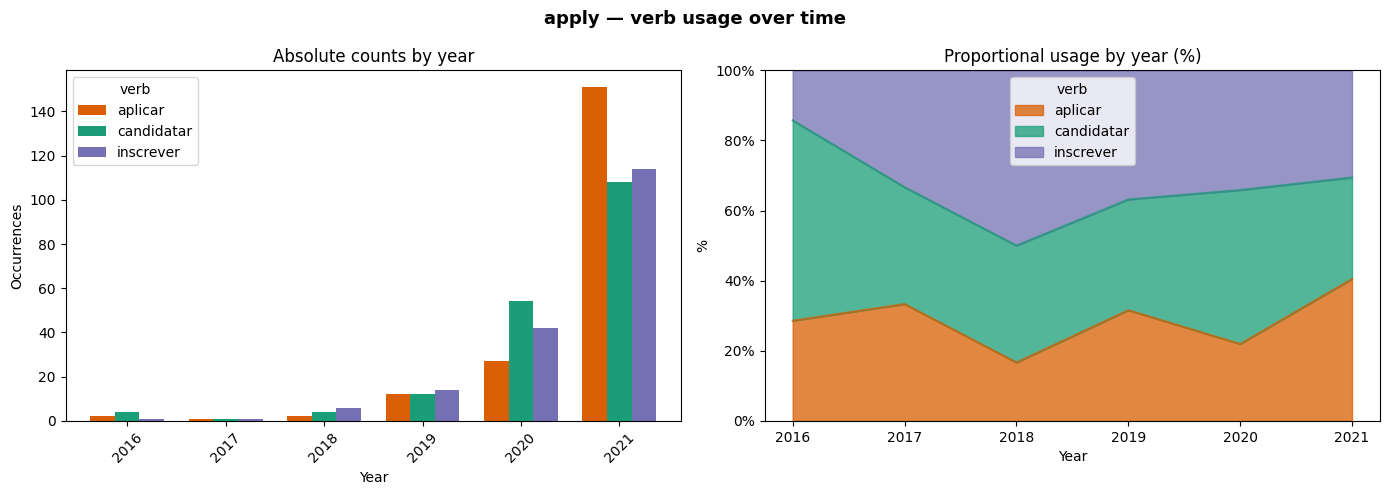


Absolute counts:
verbo  aplicar  candidatar  inscrever
ano                                  
2016         2           4          1
2017         1           1          1
2018         2           4          6
2019        12          12         14
2020        27          54         42
2021       151         108        114

Proportions (%):
verbo  aplicar  candidatar  inscrever
ano                                  
2016      28.6        57.1       14.3
2017      33.3        33.3       33.3
2018      16.7        33.3       50.0
2019      31.6        31.6       36.8
2020      22.0        43.9       34.1
2021      40.5        29.0       30.6


In [ ]:
# ── 8. Diachronic analysis: verb usage over time ──────────────────────────────
# For each term, shows absolute counts and proportional usage per year.

VERB_COLORS = {
    "aplicar":    "#d95f02",
    "candidatar": "#1b9e77",
    "inscrever":  "#7570b3",
}

# count by year and verb
por_ano = (
    relevante.groupby(['ano', 'verbo'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# proportions
por_ano_pct = por_ano.div(por_ano.sum(axis=1), axis=0) * 100

# loan proportion (aplicar vs. all)
loan_verbs   = [v for v in LOAN_FORMS.get('apply', []) if v in por_ano.columns]
native_verbs = [v for v in por_ano.columns if v not in loan_verbs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('apply — verb usage over time', fontsize=13, fontweight='bold')

# absolute counts
colors_abs = [VERB_COLORS.get(v, '#999999') for v in por_ano.columns]
por_ano.plot(kind='bar', ax=axes[0], color=colors_abs, width=0.75)
axes[0].set_title('Absolute counts by year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Occurrences')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='verb')

# proportions as stacked area
colors_pct = [VERB_COLORS.get(v, '#999999') for v in por_ano_pct.columns]
por_ano_pct.plot(kind='area', ax=axes[1], color=colors_pct,
                 alpha=0.75, stacked=True)
axes[1].set_title('Proportional usage by year (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('%')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylim(0, 100)
axes[1].legend(title='verb')

plt.tight_layout()
plt.savefig('apply_diacronico.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAbsolute counts:')
print(por_ano)
print('\nProportions (%):')
print(por_ano_pct.round(1))

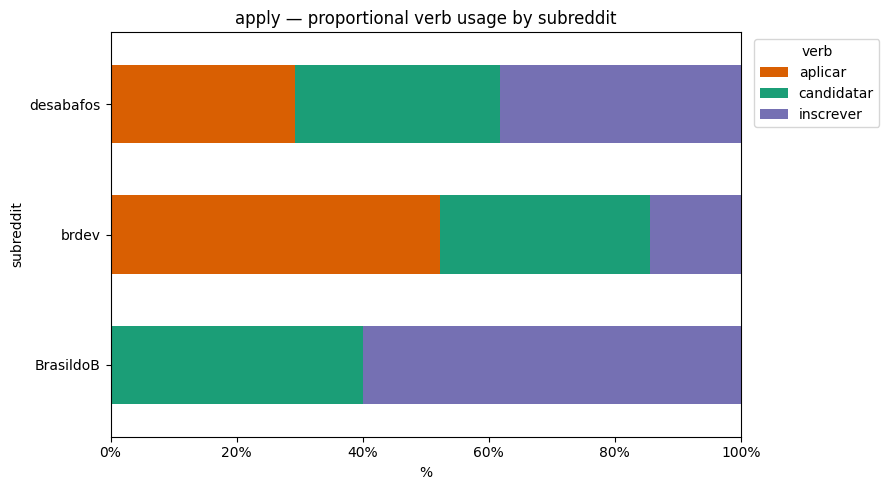


Absolute counts by subreddit:
verbo      aplicar  candidatar  inscrever
subreddit                                
BrasildoB        0           4          6
brdev           80          51         22
desabafos      115         128        150

Proportions (%):
verbo      aplicar  candidatar  inscrever
subreddit                                
BrasildoB      0.0        40.0       60.0
brdev         52.3        33.3       14.4
desabafos     29.3        32.6       38.2


In [ ]:
# ── 9. Distribution by subreddit ─────────────────────────────────────────────
# Proportional usage of each verb per subreddit.

por_sub = (
    relevante.groupby(['subreddit', 'verbo'])
    .size()
    .unstack(fill_value=0)
)
por_sub_pct = por_sub.div(por_sub.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors_sub = [VERB_COLORS.get(v, '#999999') for v in por_sub_pct.columns]
por_sub_pct.plot(kind='barh', ax=ax, color=colors_sub,
                 stacked=True, width=0.6)
ax.set_title('apply — proportional verb usage by subreddit')
ax.set_xlabel('%')
ax.set_ylabel('subreddit')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 100)
ax.legend(title='verb', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('apply_subreddits.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAbsolute counts by subreddit:')
print(por_sub)
print('\nProportions (%):')
print(por_sub_pct.round(1))

In [ ]:
# ── 10. Export curated data ────────────────────────────────────────────────────

relevante.to_csv('apply_curated_final.csv', index=False)
files.download('apply_curated_final.csv')
print(f'Exported: apply_curated_final.csv ({len(relevante)} rows)')